# Customer Shopping Behavior Analysis

## Objective
Analyze customer data to understand spending patterns.

## Key Questions
- What factors influence spending?
- Which products generate the most revenue?
- Does age affect purchasing behavior?

In [2]:
import pandas as pd
df = pd.read_csv("customer_shopping_behavior.csv")
df.head(5)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,Weekly
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,M,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly
2,3157,18,Female,Shirt,Clothing,50.0,Montana,M,Black,Winter,3.1,No,2-Day Shipping,No,18.0,Cash,Monthly
3,1687,22,Male,Gloves,Accessories,75.0,Illinois,L,Red,Fall,4.2,No,Store Pickup,No,25.0,Cash,Annually
4,2929,40,Female,Jewelry,Accessories,80.0,Alabama,L,Yellow,Spring,3.6,No,Store Pickup,No,17.0,Credit Card,Weekly


In [3]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Previous Purchases', 'Payment Method',
       'Frequency of Purchases'],
      dtype='object')

In [4]:
df.dtypes

Customer ID                 int64
Age                         int64
Gender                     object
Item Purchased             object
Category                   object
Purchase Amount (USD)     float64
Location                   object
Size                       object
Color                      object
Season                     object
Review Rating             float64
Subscription Status        object
Shipping Type              object
Discount Applied           object
Previous Purchases        float64
Payment Method             object
Frequency of Purchases     object
dtype: object

In [5]:
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)     556
Location                    0
Size                      370
Color                       0
Season                      0
Review Rating             601
Subscription Status         0
Shipping Type               0
Discount Applied            0
Previous Purchases        548
Payment Method              0
Frequency of Purchases      0
dtype: int64

In [6]:
df.shape

(5050, 17)

In [7]:
df = df.dropna(subset=['Purchase Amount (USD)'])

In [8]:
df['Size'].fillna('Unknown', inplace=True)

C:\Users\ASSHAAM GLOBAL\AppData\Local\Temp\ipykernel_16004\697864052.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Size'].fillna('Unknown', inplace=True)


In [9]:
df['Previous Purchases'].describe()

count    4231.00000
mean       25.25195
std        14.51276
min         0.00000
25%        13.00000
50%        25.00000
75%        38.00000
max        50.00000
Name: Previous Purchases, dtype: float64

## Analyzing Spending Behaviour

In [10]:
#Average purchase amount in USD
df['Purchase Amount (USD)'].mean()

np.float64(144.76523587004897)

In [11]:
#Total purchase amount in USD
df['Purchase Amount (USD)'].sum()

np.float64(650574.9700000001)

In [12]:
#Total purchase amount by customer
df.groupby('Customer ID')['Purchase Amount (USD)'].sum().sort_values(ascending=False)

Customer ID
4977    1499.76
4219    1495.94
4055    1493.56
4380    1487.00
4924    1485.92
         ...   
2697      20.00
4225      19.69
4636      16.88
5076      12.41
4181      10.12
Name: Purchase Amount (USD), Length: 4444, dtype: float64

#Highest purschase amoutn is 1499.76 by customer ID 4977

In [13]:
df.groupby('Frequency of Purchases')['Purchase Amount (USD)'].sum().sort_values(ascending=False)

Frequency of Purchases
Monthly           186024.45
Quarterly         164524.52
Weekly            163301.00
Every 3 Months     35602.00
Annually           35082.00
Bi-Weekly          33681.00
Fortnightly        32360.00
Name: Purchase Amount (USD), dtype: float64

#Customer who make monthly purchase tend to spend more.

In [14]:
df.groupby('Frequency of Purchases')['Purchase Amount (USD)'].mean().sort_values(ascending=False)

Frequency of Purchases
Monthly           243.806619
Weekly            230.001408
Quarterly         221.135108
Bi-Weekly          60.577338
Annually           60.382100
Every 3 Months     60.138514
Fortnightly        59.051095
Name: Purchase Amount (USD), dtype: float64

#What factors affect spending?

In [15]:
df.groupby('Location')['Purchase Amount (USD)'].mean().sort_values(ascending=False)

Location
Chicago           773.372804
Los Angeles       758.180776
Phoenix           739.627419
Houston           688.450303
New York          518.311019
Alaska             67.597222
Pennsylvania       66.567568
Arizona            66.553846
West Virginia      63.734940
Washington         63.328767
Nevada             63.272727
Tennessee          62.937500
North Dakota       62.891566
Utah               62.577465
Michigan           62.095890
Virginia           62.062500
New Mexico         61.901235
Rhode Island       61.444444
Iowa               61.328571
Mississippi        61.123457
Illinois           61.074468
Texas              61.037975
Massachusetts      60.888889
North Carolina     60.812500
Ohio               60.743590
Arkansas           60.691358
Wyoming            60.690141
South Dakota       60.514286
Idaho              60.447917
Montana            60.319588
Nebraska           59.566667
New Hampshire      59.422535
Alabama            58.988889
California         58.927083
India

In [16]:
df.groupby(['Location', 'Frequency of Purchases'])['Purchase Amount (USD)'].mean()

Location  Frequency of Purchases
Alabama   Annually                  57.777778
          Bi-Weekly                 55.933333
          Every 3 Months            61.777778
          Fortnightly               66.562500
          Monthly                   47.384615
                                      ...    
Wyoming   Every 3 Months            67.777778
          Fortnightly               71.818182
          Monthly                   68.285714
          Quarterly                 55.888889
          Weekly                    56.833333
Name: Purchase Amount (USD), Length: 362, dtype: float64

In [17]:
df.groupby(['Location', 'Frequency of Purchases'])['Purchase Amount (USD)'] \
  .mean() \
  .reset_index() \
  .sort_values('Purchase Amount (USD)', ascending=False) \
  .head(10)

,Location,Frequency of Purchases,Purchase Amount (USD)
277,Phoenix,Weekly,871.729630
35,Chicago,Monthly,828.334737
36,Chicago,Quarterly,806.058000
127,Los Angeles,Weekly,784.471579
125,Los Angeles,Monthly,756.159268
126,Los Angeles,Quarterly,733.419459
80,Houston,Monthly,729.557429
276,Phoenix,Quarterly,698.710690
231,New York,Quarterly,688.837273
82,Houston,Weekly,679.588750


Location & Frequency:
Phoenix has the highest spending, especially weekly buyers.
Chicago shows consistently high spending across all frequencies.
Houston and New York have lower average spending.

In [18]:
df['Season'] = df['Season'].replace({'Fall': 'Autumn'})

In [19]:
df.groupby('Season')['Purchase Amount (USD)'] \
  .agg(['mean', 'count'])

,mean,count
Season,,
Autumn,160.249107,1142
Spring,138.954721,1146
Summer,137.822275,1090
Winter,141.668548,1116


Seasonality:
Autumn is the highest spending season.
Other seasons show similar, lower spending levels.

In [20]:
df.groupby('Subscription Status')['Purchase Amount (USD)'] \
  .agg(['mean', 'count'])

,mean,count
Subscription Status,,
No,122.307872,3172
Yes,198.649319,1322


Subscription Status:
Subscribers spend significantly more (~198 USD) than non-subscribers (~122 USD).
Subscription is a strong indicator of high-value customers.

In [21]:
df.groupby('Shipping Type')['Purchase Amount (USD)'] \
  .agg(['mean', 'count'])

,mean,count
Shipping Type,,
2-Day Shipping,60.872642,636
Express,271.274546,915
Free Shipping,60.464129,683
Next Day Air,58.617378,656
Standard,257.816396,949
Store Pickup,59.887023,655


Shipping Type:
Express and Standard shipping are linked to higher spending.
Other shipping types show much lower averages.

#Note: This likely reflects customer behaviour (high spenders choose faster shipping), not a direct cause of spending.

In [22]:
df['Age'].unique()

array([22, 51, 18, 40, 23, 62, 61, 37, 42, 46, 64, 57, 68, 56, 52, 30, 21,
       58, 33, 60, 41, 34, 66, 38, 49, 69, 70, 43, 39, 59, 53, 36, 44, 26,
       29, 50, 47, 65, 19, 55, 20, 48, 24, 35, 67, 45, 63, 25, 31, 28, 27,
       32, 54])

In [23]:
bins = [17, 25, 35, 45, 55, 65, 75]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [24]:
df.groupby('Age_Group')['Purchase Amount (USD)'] \
  .agg(['mean', 'count'])

C:\Users\ASSHAAM GLOBAL\AppData\Local\Temp\ipykernel_16004\3889788756.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_Group')['Purchase Amount (USD)'] \


,mean,count
Age_Group,,
18-25,147.566117,667
26-35,138.617044,849
36-45,132.955600,834
46-55,146.370474,865
56-65,148.562918,867
65+,165.444223,412


Age Group:
65+ age group spends the most.
56–65 and 18–25 also show relatively high spending.
Middle age groups (26–45) spend less on average.

### Overall
Spending is influenced by location, subscription status, age, and season.
Shipping type reflects spending behaviour rather than causing it.

In [25]:
df['Category'].unique()

array(['Clothing', 'Accessories', 'Outerwear', 'Electronics', 'Footwear'],
      dtype=object)

In [26]:
df['Item Purchased'].unique()

array(['T-shirt', 'Sunglasses', 'Shirt', 'Gloves', 'Jewelry', 'Shorts',
       'Hat', 'Handbag', 'Coat', 'Laptop', 'Hoodie', 'Jacket', 'Shoes',
       'Phone', 'Pants', 'Backpack', 'Socks', 'Jeans', 'Belt', 'Blouse',
       'Sandals', 'Skirt', 'Sweater', 'Scarf', 'Sneakers', 'Bag',
       'Headphones', 'Watch', 'Boots', 'Dress'], dtype=object)

In [27]:
df.groupby(['Location', 'Age_Group'])['Purchase Amount (USD)'] \
  .mean() \
  .reset_index() \
  .sort_values('Purchase Amount (USD)', ascending=False) \
  .head(10)

C:\Users\ASSHAAM GLOBAL\AppData\Local\Temp\ipykernel_16004\2617700177.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Location', 'Age_Group'])['Purchase Amount (USD)'] \


,Location,Age_Group,Purchase Amount (USD)
251,Phoenix,65+,998.680000
35,Chicago,65+,998.314167
119,Los Angeles,65+,903.900833
30,Chicago,18-25,810.084000
249,Phoenix,46-55,797.284375
116,Los Angeles,36-45,794.673529
117,Los Angeles,46-55,775.700000
31,Chicago,26-35,775.495000
246,Phoenix,18-25,765.755714
118,Los Angeles,56-65,760.892500


In [28]:
df.groupby(["Age_Group", "Item Purchased"]).size().unstack()

C:\Users\ASSHAAM GLOBAL\AppData\Local\Temp\ipykernel_16004\2720499232.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Age_Group", "Item Purchased"]).size().unstack()


Item Purchased,Backpack,Bag,Belt,Blouse,Boots,Coat,Dress,Gloves,Handbag,Hat,...,Shirt,Shoes,Shorts,Skirt,Sneakers,Socks,Sunglasses,Sweater,T-shirt,Watch
Age_Group,,,,,,,,,,,,,,,,,,,,,
18-25,16,12,26,23,19,29,29,24,23,24,...,42,26,28,27,28,23,21,31,26,9
26-35,39,13,32,33,28,33,22,31,26,26,...,61,38,32,30,24,34,34,26,33,10
36-45,34,17,37,35,24,20,32,22,23,37,...,44,25,22,21,26,22,27,29,25,16
46-55,20,14,33,35,37,33,31,21,33,26,...,39,61,35,33,33,30,34,32,27,15
56-65,25,17,22,29,27,36,34,28,33,35,...,52,47,37,33,22,29,36,34,29,16
65+,10,7,14,17,11,11,18,14,19,7,...,17,22,9,15,12,21,12,14,10,2


In [29]:
import matplotlib.pyplot as plt


C:\Users\ASSHAAM GLOBAL\AppData\Local\Temp\ipykernel_16004\1961432340.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ax = filtered_df.groupby(["Age_Group", "Category"]).size().unstack().plot(


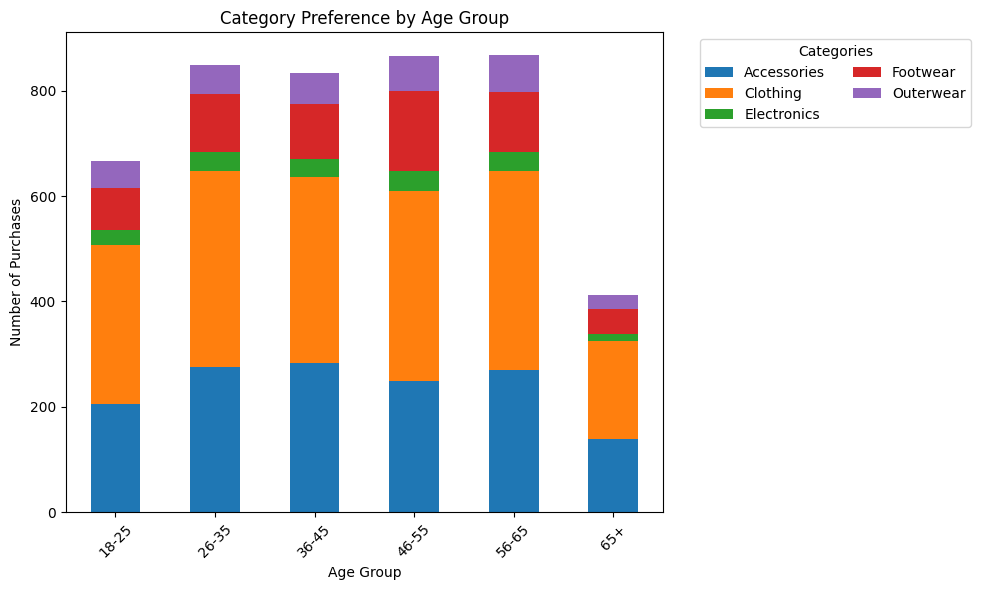

In [30]:
top_category = df["Category"].value_counts().head(5).index
filtered_df = df[df["Category"].isin(top_category)]

ax = filtered_df.groupby(["Age_Group", "Category"]).size().unstack().plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Category Preference by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Purchases")

plt.legend(
    title="Categories",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    ncol=2
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Across all locations:

Clothing dominates   
Electronics and Accessories follow  
Footwear & Outerwear are minimal  

Customer purchasing behavior is relatively consistent across locations, with Clothing being the dominant category in all regions. However, a few locations contribute disproportionately higher sales, indicating potential high-value markets that could be targeted for increased marketing efforts.

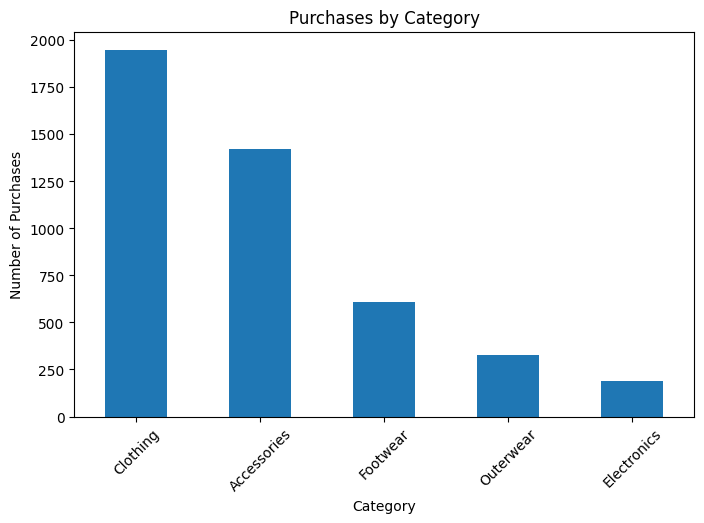

In [31]:
df["Category"].value_counts().plot(kind="bar", figsize=(8,5))
plt.title("Purchases by Category")
plt.xlabel("Category")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=45)
plt.show()

In [32]:
category_sales = df.groupby("Category")["Purchase Amount (USD)"].sum().sort_values(ascending=False)

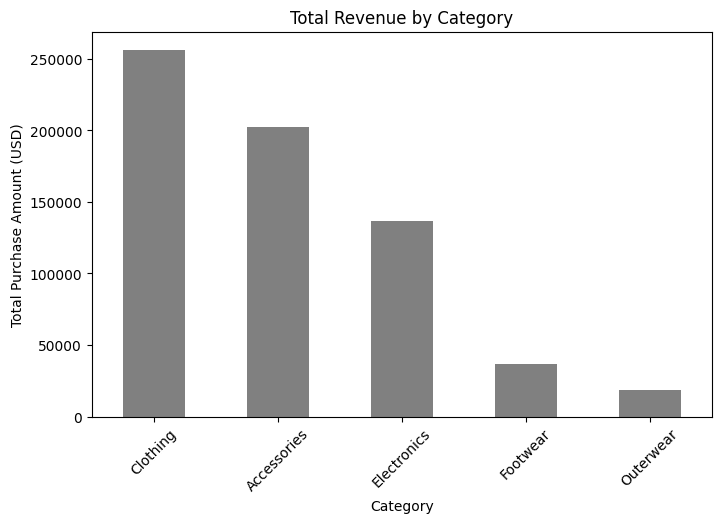

In [33]:
category_sales.plot(kind="bar", figsize=(8,5), color="gray")

plt.title("Total Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Total Purchase Amount (USD)")
plt.xticks(rotation=45)

plt.show()

Clothing is the primary revenue driver, significantly outperforming all other categories. This suggests strong customer demand and highlights an opportunity to prioritize inventory, promotions, and marketing efforts in this category.

In [34]:
location_category = df.groupby(["Location", "Category"]).size().unstack()

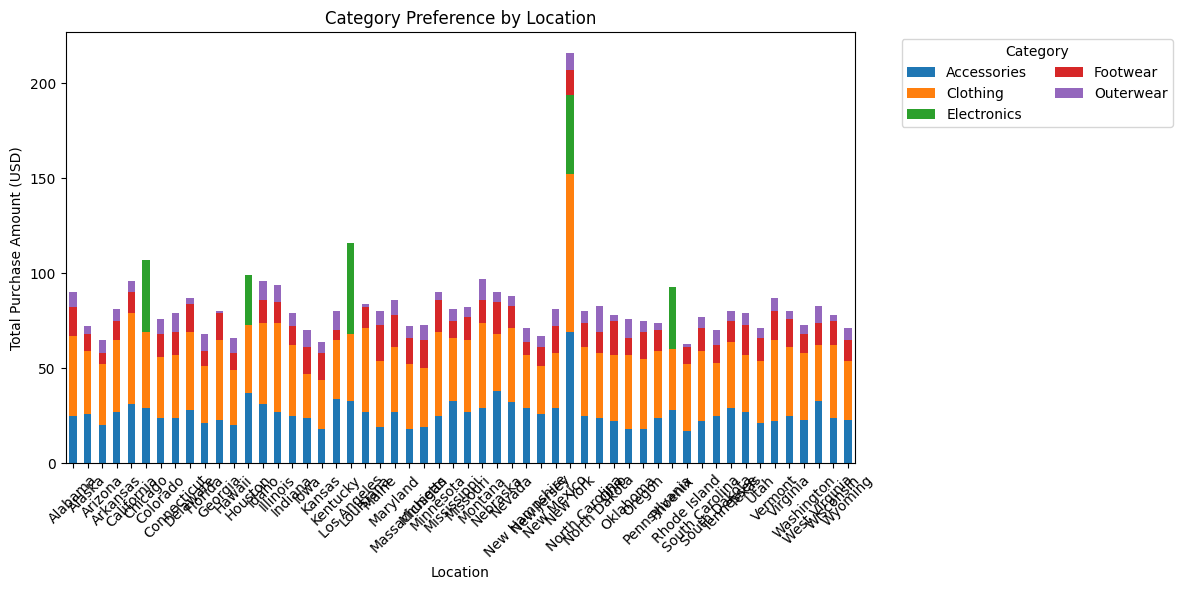

In [35]:
location_category.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Category Preference by Location")
plt.xlabel("Location")
plt.ylabel("Total Purchase Amount (USD)")
plt.xticks(rotation=45)

plt.legend(
    title="Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    ncol=2
)

plt.tight_layout()
plt.show()

Customers aged 26–65 represent the most active purchasing segment, with consistently higher transaction volumes across all categories. Clothing remains the most preferred category across all age groups, while older customers (65+) show significantly lower engagement, indicating a potential gap in targeting or accessibility.

On a stronger behaviour insights:  
Product preferences remain largely consistent across age groups, suggesting that purchasing behavior is driven more by product appeal than demographic differences. However, middle-aged customers (26–65) contribute the majority of purchases, making them the key target segment for revenue growth.

In [36]:
season_category = df.groupby(["Season", "Category"]).size().unstack()

In [37]:
season_pct = season_category.div(season_category.sum(axis=1), axis=0)

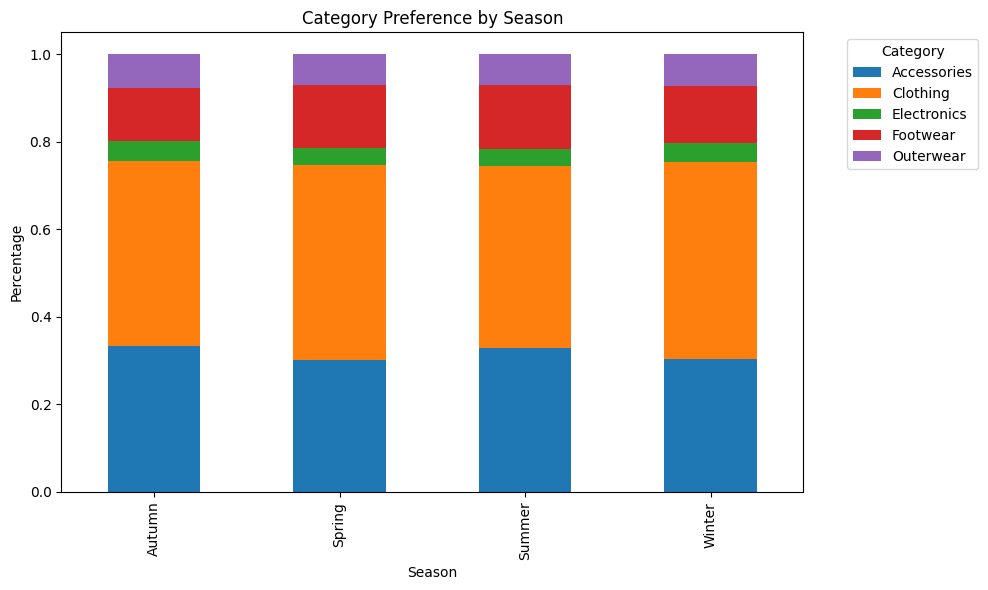

In [38]:
season_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Category Preference by Season")
plt.xlabel("Season")
plt.ylabel("Percentage")

plt.legend(
    title="Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

Customer purchasing behavior across product categories remains relatively consistent throughout the year, with Clothing and Accessories dominating sales in all seasons. Seasonal variation appears minimal, suggesting stable demand patterns rather than strong seasonality effects.

In [39]:
discount_effect = df.groupby("Discount Applied")["Purchase Amount (USD)"].mean()
print(discount_effect)

Discount Applied
No     130.558153
Yes    162.852858
Name: Purchase Amount (USD), dtype: float64


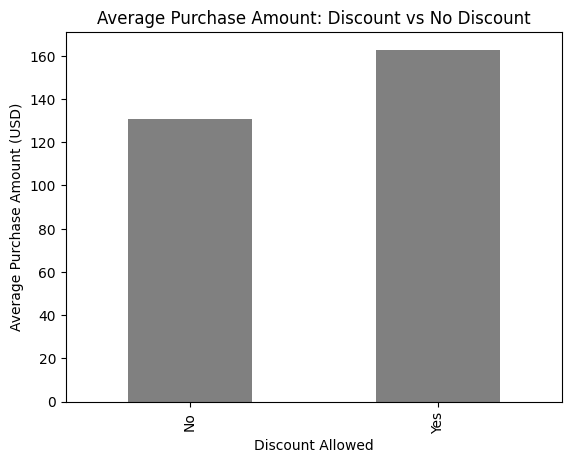

In [40]:
discount_effect.plot(kind="bar", color="gray")

plt.title("Average Purchase Amount: Discount vs No Discount")
plt.xlabel("Discount Allowed")
plt.ylabel("Average Purchase Amount (USD)")

plt.show()

Customers tend to spend more when discounts are offered, with the average purchase amount increasing significantly compared to non-discounted transactions. This suggests that discounts encourage higher spending per order rather than just increasing purchase frequency.